Saving 1936ec6d-ddc2-4065-b0b3-e9e54905f496.png to 1936ec6d-ddc2-4065-b0b3-e9e54905f496 (1).png
Identified Shape: Circle


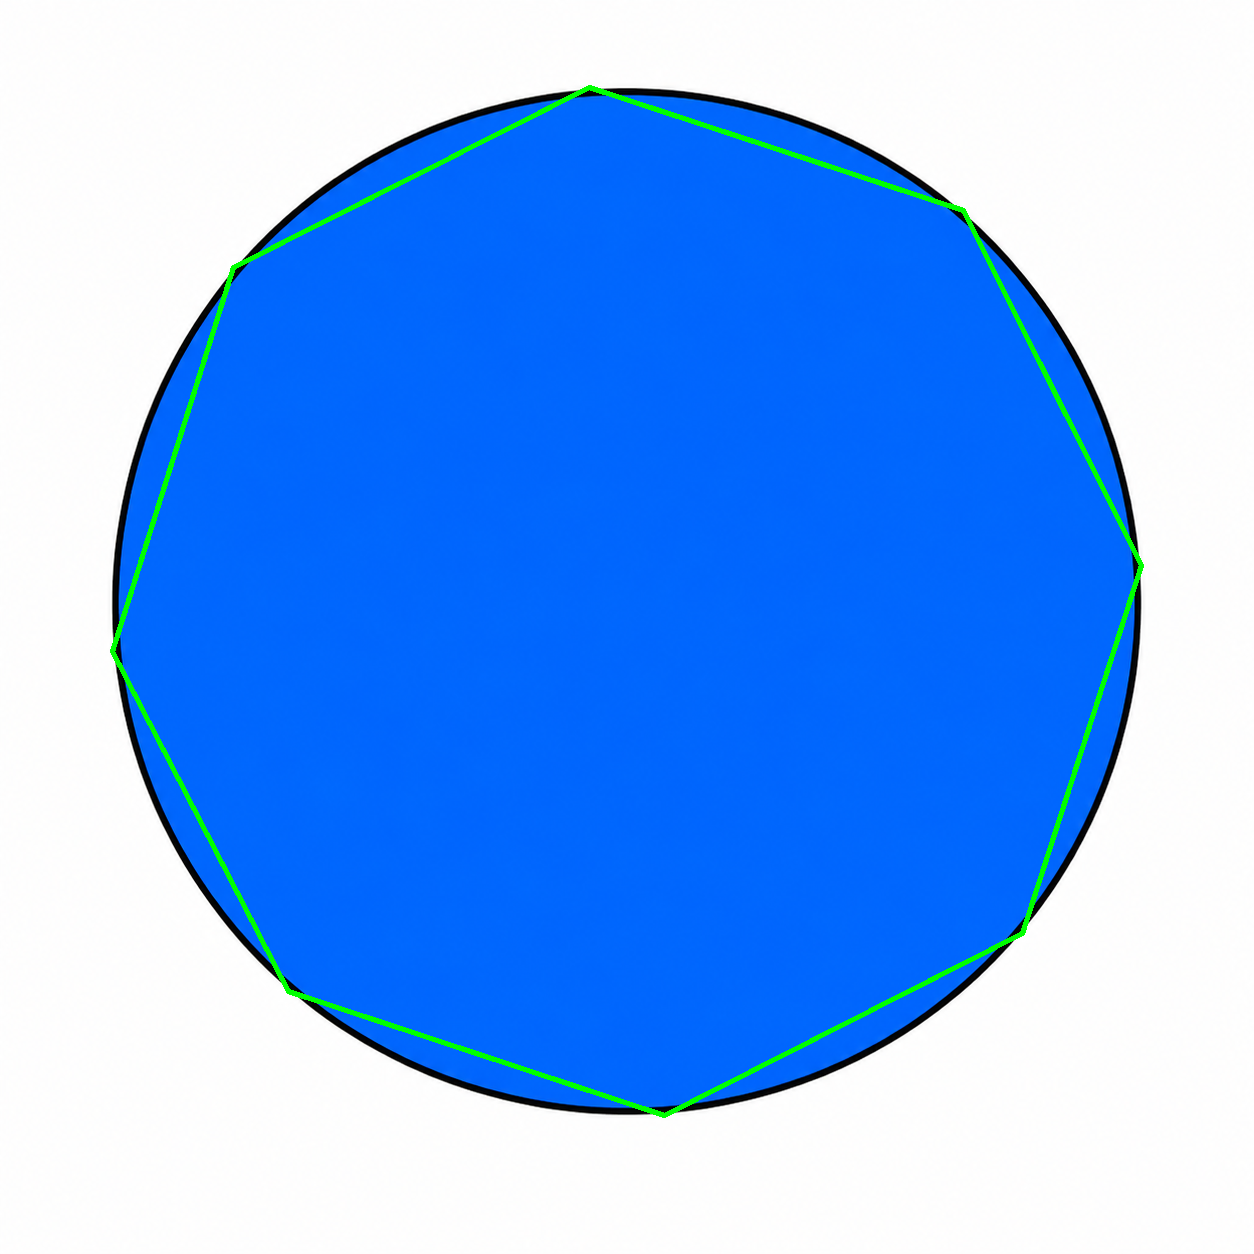

In [5]:
from google.colab import files
import cv2
import numpy as np

# Upload the image
uploaded = files.upload()

# Get uploaded file name
image_name = list(uploaded.keys())[0]

# Read the image
img = cv2.imread(image_name)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
gray = cv2.GaussianBlur(gray, (5,5), 0)

# Apply threshold
_, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Detect shape
for cnt in contours:

    # Ignore very small objects
    if cv2.contourArea(cnt) < 500:
        continue

    # Approximate contour
    approx = cv2.approxPolyDP(cnt, 0.04 * cv2.arcLength(cnt, True), True)

    sides = len(approx)

    if sides == 3:
        shape = "Triangle"

    elif sides == 4:
        x, y, w, h = cv2.boundingRect(approx)
        ratio = w / float(h)

        if 0.95 <= ratio <= 1.05:
            shape = "Square"
        else:
            shape = "Rectangle"

    else:
        shape = "Circle"

    print("Identified Shape:", shape)

    # Draw contour and label
    cv2.drawContours(img, [approx], -1, (0,255,0), 3)
    cv2.putText(img, shape, (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (255,0,0), 2)

# Display image
from google.colab.patches import cv2_imshow
cv2_imshow(img)